# pyGAlib tutorial: Roles of nodes in modular networks
Authors: **Gorka Zamora-López, Ph.D.**

<div align="left">
<img src="Images/Logo_CAS_ICS.png" align="left" width="254" alt="logo ICS">
</div>


<br>
<br>

---------------------

This tutorial notebook illustrates the tools in *pyGAlib* to study the position that nodes take in modular (and hierarchical) networks. Usually, this involves to first compute the **hubness** and the **participation index** of every node, and then to project them on a map made of these two parameters as illustrated in the Figure below. 

ADD AN ILLUSTRATIVE FIGURE HERE 

We will do the following:

1. *Quick example*: Mapping the roles of nodes in an empirical network (Klimm et al, 2014).
2. *In detail*: Local versus global hubness.
3. *In detail*: Local and global participation indices.
4. *Looking back*: The original parametrization and its limitations (Guimerà & Amaral 2005a, 2005b).
5. (Advanced) Expected mapping of roles in special cases:
    * Random graphs.
    * Random modular graphs (block-model).
    * Surrogates for empirical networks.


All the functions employed here to characterise the roles of nodes are located in the module *metrics.py*. To obtain more information the user can revise the documentation in an interactive window. As usual, type `help(galib.metrics)` (or `metrics?` witin an IPython or Jupyter Notebook interactive session) to get a list of all network generation functions. Specific instructions for each function is accessed as `help(galib.FunctionName)` (or `galib.FunctionName?`).


#### References

* F. Klimm, J. Borge-Holthoefer, N. Wessel, J. Kurths & G. Zamora-López (2014) [Individual nodeʼs contribution to the mesoscale of
complex networks](http://dx.doi.org/10.1088/1367-2630/16/12/125006) New J. Physics 16, 125006.
* R. Guimerà & L.A.N. Amaral (2005a) [Cartography of complex networks: modules and universal roles](http://dx.doi.org/10.1088/1742-5468/2005/02/P02001). J. Stat. Mechs. 2005.02, P02001.
* R. Guimerà & L.A.N. Amaral (2005b) [Functional cartography of complex metabolic networks](http://doi.org/10.1038/nature03286). Nature 433, 895-900.

## Import the dependencies

Running this Notebook requires a __*Python*__ (>=3.6) installation together with __*NumPy*__ (>1.6) and __*pyGAlib*__ (>=2.1). The package __*Matplotlib*__ is required for the visualizations. Please make sure these packages are installed in the same environment in which this notebook is running.


In [1]:
# Python standard library imports

# Third-party imports
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Local libraries
import galib


## 1. Quick example: Mapping the roles of nodes in an empirical network.

The role (or position) a node takes in a modular structure can be identified by estimating a few parameters. WRITE A GENERAL DESCRIPTION HERE OF THE ROLES AND THE PARAMETERS (local hubmess, global hubness, participation index and dispersion index), Klimm et al. (2014). 

ADD AN ILLUSTRATIVE FIGURE HERE: VARIOS NODES IN A MODULAR NET + SKEMATIC OF THE THREE PLOTS.



We begin by illustrating the quickest manner to compute these parameters and plot the nodes accordingly. For that we first load a sample empirical network.


### Load an empirical network

We provide four empirical networks to choose from in this example: 

+ Structural connectivity of between cortical regions in cats ($N = 53$ nodes and $L = 8xx$; $\rho = 0.3$).
+ Zachary karate-club social network ($N = 34$ and $L = xxxx$ edges; $\rho = x.xx$).
+ Dolphins social network (N = 62 and $L = xxx$ edges; $\rho = x.xx$).
+ Acquitance network between characters in *Les Miserables* ($N = 77$ and $L = xxxx$ edges; $\rho = x.xx$).


> **NOTE**: To map the roles we first need a parcellation of the nodes in a network., or run a perform community detection algorithm. For the illustrative puroposes here, we will load precomputed partition of the network.


Number of nodes N = 53   edges: L = 686  |  Density: 0.380



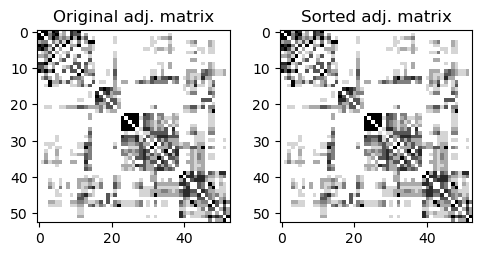

In [2]:
## LOAD AN EMPIRICAL NETWORK AND SORT IT BY COMMUNITIES

# 1) Load an empirical network (CHOOSE ONE realnet)
dataroot = "./Data/"
## Structural cortico-cortical connectivity of cats
net = np.loadtxt(dataroot + 'Cat53_cortex_sym.txt', dtype='float64')
partition = galib.tools.LoadPartition( dataroot + 'Cat53_Partition.txt' )

## Zachary karate club
# net = np.loadtxt(dataroot + 'Zachary.txt', dtype='uint8')
# partition = galib.tools.LoadPartition( dataroot + 'xxxxxxx' )

## Dolphins social network
# net = galib.tools.LoadFromPajek(dataroot + 'Dolphins.net', getlabels=False)
# partition = galib.tools.LoadPartition( dataroot + 'xxxxxxx' )

## Les Miserables character network
# net = galib.tools.LoadFromPajek(dataroot + 'LesMiserables.net', getlabels=False)
# partition = galib.tools.LoadPartition( dataroot + 'xxxxxxx' )


# 2) Sort the nodes in the adjacency matrix by communities
nodelist = []
for com in partition:
    nodelist += com
net_sorted = galib.tools.ExtractSubmatrix(net, nodelist)



#######################################################################################
## FEEDBACK, NO NEED TO EDIT FROM HERE ################################################

# Print some feedback ...
N = len(net)
L = int( 0.5 * net.sum() )
dens = galib.Density(net)
print( f"Number of nodes N = {N:d}   edges: L = {L:d}  |  Density: {dens:1.3f}" )
print()


# Visualize the original and the sorted adjacency matrices
plt.figure(figsize=(5,2.5))

plt.subplot(1,2,1)
plt.title( 'Original adj. matrix' )
plt.imshow(net, cmap='gray_r')

plt.subplot(1,2,2)
plt.title( 'Sorted adj. matrix' )
plt.imshow(net_sorted, cmap='gray_r')

plt.tight_layout()



As seen ...

### Parametrization of roles 

Are networks directed?  net: False  |  wnet1: False  |  wnet2: False
Are weights symmetric?  net: True  |  wnet1: False  |  wnet2: False



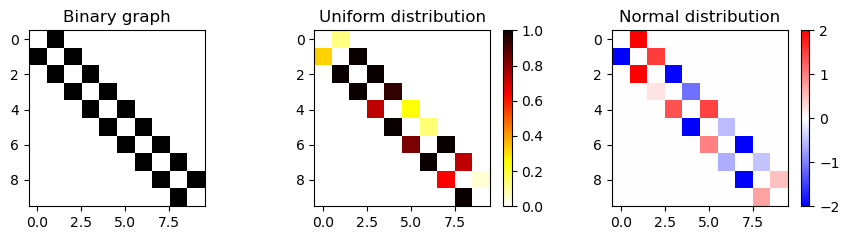

In [3]:
## COMPUTE THE FOUR PARAMETERS PER NODE: 
## global hubness, local hubness, (global) participation index and (local) dispersion index 

ghubness, lhubness, pindex, dindex = galib.RolesNodes(net, partition)



#######################################################################################
## FEEDBACK, NO NEED TO EDIT FROM HERE ################################################

# Assign colors to the nodes by community
colorlist = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf' ]
nodecolors = zeros(N, dtype='<U8')
for c,com in enumerate(partition):
    nodecolors[com] = colorlist[c]


plt.figure(figsize=(9,2.5))

# 1) Plot local hubness vs global hubness
plt.subplot(1,3,1)
# Plot the data
plt.scatter(lhubness,ghubness, color=colornodes, s=20)
# Draw the axis (look for other manner!)
plt.plot((-100,100),(0,0), color='gray', lw=1.0, zorder=0)
plt.plot((0,0),(-100,100), color='gray', lw=1.0, zorder=0)
# Draw the significance lines
plt.plot((-100,100),(2.5,2.5), ls='--', color='gray', lw=0.5, zorder=0)
plt.plot((-100,100),(-2.5,-2.5), ls='--', color='gray', lw=0.5, zorder=0)
plt.plot((2.5,2.5),(-100,100), ls='--', color='gray', lw=0.5, zorder=0)
plt.plot((-2.5,-2.5),(-100,100), ls='--', color='gray', lw=0.5, zorder=0)

# Axis properties
#plt.xlim(floor(lhubness.min()), floor(lhubness.max()+1))
#plt.ylim(floor(ghubness.min()), floor(ghubness.max()+1))
plt.xlim(-5,5)
plt.ylim(-6,6)
plt.xlabel('Local hubness', fontsize=14)
plt.ylabel('Global hubness', fontsize=14)


# 2) Plot node participation vs. global hubness
plt.subplot(1,3,2)

# Plot the data
plt.scatter(pindex,ghubness, color=colornodes, s=20)
# Draw the axis (look for other manner!)
plt.plot((-100,100),(0,0), color='gray', lw=1.0, zorder=0)
#plt.plot((0,0),(-100,100), color='gray', lw=1.0, zorder=0)
# Draw the significance lines
plt.plot((-100,100),(2.5,2.5), ls='--', color='gray', lw=0.5, zorder=0)
plt.plot((-100,100),(-2.5,-2.5), ls='--', color='gray', lw=0.5, zorder=0)
plt.plot((0.3333,0.3333),(-100,100), ls='--', color='gray', lw=0.5, zorder=0)
plt.plot((0.6666,0.6666),(-100,100), ls='--', color='gray', lw=0.5, zorder=0)

# Axis properties
plt.xlim(-0.01,1.01)
plt.ylim(-6,6)
plt.xlabel('Participation Index', fontsize=14)
plt.ylabel('Global hubness', fontsize=14)


# 3) Plot node dispersion vs. node participation
# Compute the background limit curves for the dindex vs. pindex plot
ddata = np.arange(-0.1,1.001,0.001)
pdata = MaxDispersionCurve(ddata, 4)

plt.subplot(1,3,3)

# Plot the background lines
plt.plot(pdata, ddata, color='gray', zorder=0)
plt.plot((0,1),(0,1), color='gray', zorder=0)
# Include the shades
plt.fill_between((0,1.2), (-0.5,-0.5), (0,1.2), color='gray', alpha=0.2)
plt.fill_between(pdata, ddata, 1.1*np.ones(len(ddata)), color='gray', alpha=0.2)
# Plot the data
plt.scatter(pindex,dindex, color=colornodes, s=20)
plt.xlabel('Participation Index', fontsize=14)
plt.ylabel('Dispersion Index', fontsize=14)
plt.xlim(-0.01,1.01)
plt.ylim(-0.01,1.01)
plt.grid()

plt.tight_layout()


As expected, the two weighted networks are still undirected, like the binary graph, but their link weights are no longer symmetric.

<br>

On the other hand, seting `sym_w = True` the function will return a weighted matrix as symmetric as possible. To do so, `SeedRandomWeights()` will treat reciprocal ($ i \leftrightarrow j$) and purely directed ($i \to j$) links differently; seeding symmetric weights ($w_{ji} = w_{ij}$) for reciprocal links and independent weights ($w_{ij}$) for directed ones. Therefore, 

- if $A$ represents an ***undirected graph***, the result is a symmetric weighted matrix (the default behaviour), but
- if $A$ is a ***directed graph***, then its reciprocal links (if any) will be given symmetric weights, while the purely directed links will each obtain an independent weight.



### 1.2. – Directed graphs

In the following we show two examples for the default (`sym_w = None`) and the symmetric (`sym_w = True`) modes on digraphs. For completeness, we will not only visually the resulting weighted adjacency matrix, but we will include the results for the reciprocal and directed components of the networks. Meaning, we will show separately the subset of the digraph made of reciprocal edges (where $A_{ij} = A_{ji} = 1$), and subset made of purely directed arcs (say, $A_{ij} = 1$ but $A_{ji} = 0$).

We begin by generating a digraph with weights seeded completely randomly (default case, when `sym_w = None`).

Are networks directed?  net: True  |  wnet: True  |  undir. component: False  |  dir. component: True
Are weights symmetric?  net: False  |  wnet: False  |  undir. component: False  |  directed component: False



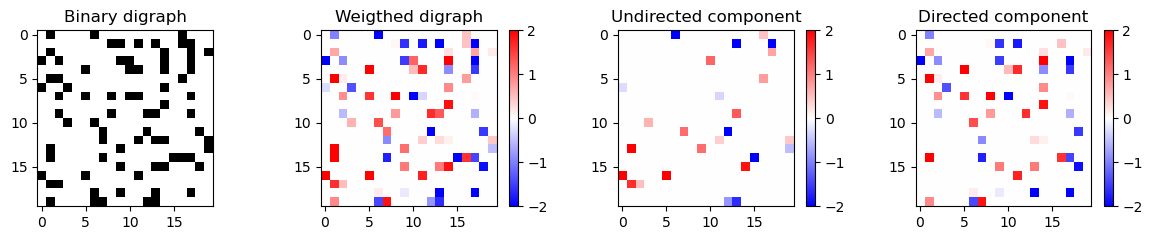

In [4]:
## GENERATE A DIRECTED GRAPH AND SEED RANDOM WEIGHTS TO ITS LINKS (ARCS)

# 1) We create a small random digraph
N = 20
linkprob = 0.2
dirnet = galib.ErdosRenyiGraph(N,linkprob, directed=True)

# 2) Assign random weights from a normal distribution of mean=0 and variance=2
wdirnet = galib.SeedRandomWeights(dirnet, np.random.normal, loc=0,scale=2)



#######################################################################################
## FEEDBACK, NO NEED TO EDIT FROM HERE ################################################

# Define the masks for the reciprocal and the directed components
mask = dirnet.astype(np.bool)
mask_und = mask * mask.T
mask_dir = mask ^ mask_und

wnet_und = wdirnet * mask_und
wnet_dir = wdirnet * mask_dir

# Print some feedback ...
print( f"Are networks directed?  net: {galib.is_directed(dirnet)}  |  wnet: {galib.is_directed(wdirnet)}  |  \
undir. component: {galib.is_directed(wnet_und)}  |  dir. component: {galib.is_directed(wnet_dir)}" )
print( f"Are weights symmetric?  net: {galib.is_symmetric(dirnet)}  |  wnet: {galib.is_symmetric(wdirnet)}  |  \
undir. component: {galib.is_symmetric(wnet_und)}  |  directed component: {galib.is_symmetric(wnet_dir)}" )
print()


# Visualize all the matrices: digraph, weighted and the two components
plt.figure(figsize=(12,2.5))

plt.subplot(1,4,1)
plt.title( 'Binary digraph' )
plt.imshow(dirnet, cmap='gray_r')

plt.subplot(1,4,2)
plt.title( 'Weigthed digraph' )
plt.imshow(wdirnet, cmap='bwr')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,4,3)
plt.title( 'Undirected component' )
plt.imshow(wnet_und, cmap='bwr')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,4,4)
plt.title( 'Directed component' )
plt.imshow(wnet_dir, cmap='bwr')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()


As seen, in this default behaviour (`sym_w = None`) the function identified that the input matrix represents a directed graph and therefore sets to seed weights at random, considering every directed link (entry with $A_{ij} = 1$) independently. Even if the digraph contains a few reciprocal links ($A_{ij} = A_{ji} = 1$) shown in the undirected component, their weights are not symmetric. Notice that this is the same behaviour that would result if we had set `sym_w = False` but, in the default case, `SeedRandomWeights()` identifies which behaviour to use depending on whether the input adjacency matrix is directed or undirected.

<br>

Finally, when setting `sym_w = True` the function `SeedRandomGraphs()` will seed symmetric weights for all reciprocal links that it finds. As we show now in the following example.

Are networks directed?  net: True  |  wnet: True  |  undir. component: False  |  dir. component: True
Are weights symmetric?  net: False  |  wnet: False  |  undir. component: True  |  directed component: False



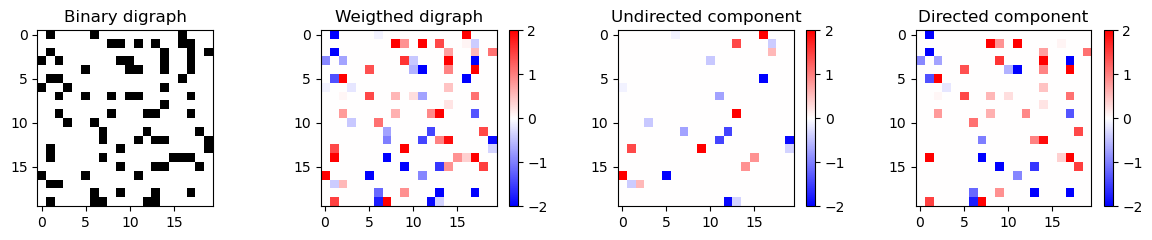

In [5]:
## GENERATE A DIRECTED GRAPH AND SEED WEIGHTS AS SYMMETRIC AS POSSIBLE

# # 1) We use the same digraph as above, or generate a new one uncommenting
# N = 20
# linkprob = 0.2
# dirnet = galib.ErdosRenyiGraph(N,linkprob, directed=True)

# 2) Assign random weights from a normal distribution of mean=0 and variance=2
# This time, set optional parameter `sym_w = True`
wdirnet = galib.SeedRandomWeights(dirnet, np.random.normal, sym_w=True, loc=0,scale=2)



#######################################################################################
## FEEDBACK, NO NEED TO EDIT FROM HERE ################################################

# Define the masks for the reciprocal and the directed components
mask = dirnet.astype(np.bool)
mask_und = mask * mask.T
mask_dir = mask ^ mask_und

wnet_und = wdirnet * mask_und
wnet_dir = wdirnet * mask_dir

# Print some feedback ...
print( f"Are networks directed?  net: {galib.is_directed(dirnet)}  |  wnet: {galib.is_directed(wdirnet)}  |  \
undir. component: {galib.is_directed(wnet_und)}  |  dir. component: {galib.is_directed(wnet_dir)}" )
print( f"Are weights symmetric?  net: {galib.is_symmetric(dirnet)}  |  wnet: {galib.is_symmetric(wdirnet)}  |  \
undir. component: {galib.is_symmetric(wnet_und)}  |  directed component: {galib.is_symmetric(wnet_dir)}" )
print()


# Visualize all the matrices: digraph, weighted and the two components
plt.figure(figsize=(12,2.5))

plt.subplot(1,4,1)
plt.title( 'Binary digraph' )
plt.imshow(dirnet, cmap='gray_r')

plt.subplot(1,4,2)
plt.title( 'Weigthed digraph' )
plt.imshow(wdirnet, cmap='bwr')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,4,3)
plt.title( 'Undirected component' )
plt.imshow(wnet_und, cmap='bwr')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,4,4)
plt.title( 'Directed component' )
plt.imshow(wnet_dir, cmap='bwr')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()

This time, with `sym_w = True` set, `SeedRandomWeights()` managed to give symmetric weights to the reciprocal edges (undirected component) while the rest of links, each receives an independent weight, as seen in the matrix for the directed component.

## 2. Generating random (di)graphs with random weights (from scratch)

As shown in the previous section, the function `SeedRandomWeights()` returns a copy of an input `adjmatrix` with random weights added to it. Therefore, weighted (random) graphs can be easily generated by creating a binary random graph first, and adding weights to it. For example, this is how we would add random uniform weights to a scale-free graph (following the rich-gets-richer method in Barabási & Albert, 2000) of $N = 10000$ nodes, and $m = 5$ links per new node:
```python
>>> wrnet = BarabasiAlbertGraph(10000, 5)
>>> wrnet = SeedRandomWeights(wrnet, numpy.random.uniform, low=0, high=1)
```

> **NOTE:** `SeedRandomWeights()` always returns a new array, instead of seeding the weights in-place to the input matrix. In the examples of Section 1 we created independent weighted versions from a binary graph. Here, we created a binary graph `wrnet` in the first line and overrode it in the second line, by calling `wrnet = SeedRandomWeights(wrnet, ...)` To do so, *NumPy* still needs to create two matrices and keep them in memory, although the first (binary) one is cleaned-up at the end of the process. This behaviour allows more flexibility than if the function would always seed the weights "in-place" to the input matrix.



While this simple procedure would work for any (random) graph we may generate in the first step, the canonical model for random graphs comes in two flavours: the $G(N,p)$ for graphs of $N$ nodes and link probability $p$, and the $G(N,L)$ model for random graphs of size $N$ and fixed number of links $L$. Given the relevance of two models and their common use, pyGAlib provides a few shortcuts to generate weighted versions of them. To generate them "from scratch", the following functions are "syntactic sugar" merging the two-call step into into one:

* `galib.models.WeightedERGraph()` 
* `galib.models.WeightedRandomGraph()` 

They inherit the parameters from both the `ErdosRenyiGraph()` (the `RandomGraph()`) function and the `SeedRandomWeights()`. Thus, they accept …

* Three mandatory positional parameters:
    - `N`: number of nodes.
    - `p`: link probability (`L`: number of links).
    - `w_dist` the random number generator function, e.g., from *NumPy* or the *SciPy* packages.
* Various optional parameters.
    - `directed`: whether a digraph or a graph is desired.
    - `selfloops`: if generation of self-loops (diagonal entries) is allowed.
    - `sym_w`: whether reciprocal edges will be given the same weight.
* Keyword arguments `**arg_w_distr` usually related to the random number generator `w_dist`. 

As an example, the following cell generates an Erdos-Renyi graph with random weights assigned from the normal distribution. The user will notice that this almost the same as the last example in Section 1.2, but with the output generated in a single function call.

Are the networks directed in ...  wrnet: True  |  undirected component: False  |  directed component: True
Are the weights symmetric in ...  wrnet: False |  undirected component: True  |  directed component: False



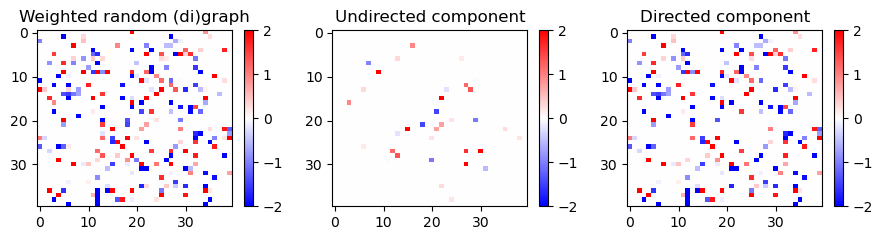

In [6]:
## GENERATE AN ERDOS-RENYI RANDOM (DI)GRAPH WITH WEIGHTS SAMPLED FROM A NORMAL DISTRIBUTION

# 1) Define the main parameters
# Positional arguments
N = 40
p = 0.15   # Between 0 and 1
w_distr = numpy.random.normal   # e.g., numpy.random.uniform

# Optional arguments
_directed = True   # True, False
_selfloops = True  # True, False
_sym_w = True      # None, True, False

# Keyword arguments (depend on the distribution chosen)
_kwargs = {'loc':0, 'scale':2}


# 2) Generate the random and weighted (di)graph
wrnet = galib.models.WeightedERGraph(N, p, w_distr, 
                                     directed = _directed, 
                                     selfloops = _selfloops, 
                                     sym_w = _sym_w,
                                     **_kwargs)


#######################################################################################
## NO NEED TO EDIT FROM HERE ##########################################################

# 3) Visualise the generated (di)graph and check the (un)directed components
# Define the masks for the reciprocal and the directed components
mask = wrnet.astype(np.bool)
mask_und = mask * mask.T
mask_dir = mask ^ mask_und

wrnet_und = wrnet * mask_und
wrnet_dir = wrnet * mask_dir

# Print some feedback ...
print( f"Are the networks directed in ...  wrnet: {galib.is_directed(wrnet)}  |  \
undirected component: {galib.is_directed(wrnet_und)}  |  directed component: {galib.is_directed(wrnet_dir)}" )
print( f"Are the weights symmetric in ...  wrnet: {galib.is_symmetric(wrnet)} |  \
undirected component: {galib.is_symmetric(wrnet_und)}  |  directed component: {galib.is_symmetric(wrnet_dir)}" )
print()


# Visualize the weighted adjacency matrix and the two components separately
plt.figure(figsize=(9,2.5))
plt.subplot(1,3,1)
plt.title( 'Weighted random (di)graph' )
plt.imshow(wrnet, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,3,2)
plt.title( 'Undirected component' )
plt.imshow(wrnet_und, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,3,3)
plt.title( 'Directed component' )
plt.imshow(wrnet_dir, cmap='bwr', aspect='auto')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()


## 3. Generation of weighted surrogates from empirical networks

Given an empirical or synthetic network $A$, a surrogate of $A$ is another network that conserves some of the constraints of $A$ but other properties are randomised. There are different manners to construct surrogate networks, depending on which properties are conserved and which are randomised. The choice depends on the questions we want to ask about $A$ and, thus, there are no "right" or "wrong" surrogate models, as long as their creation satisfies the assumptions and correctly conserve (randomise) the desired properties.

Here, we will show three types of surrogates that can be generated for weighted networks using *pyGAlib*:

1. Equivalent random (di)graphs with random weights
    - `ErdosRenyiGraph_Like()`
    - `RandomGraph_Like()`
2. Shuffle the link weights, while conserving the underlying structure
    - `ShuffleWeights()`
3. Randomise links and weights by link rewiring
    - `RewireNetwork()`



### 3.1 - Weighted random (di)graphs from empirical networks

Section 2 explained how to easily generate (random) (di)graphs and seed random weights to them, from scratch. We used functions `WeightedERGraph()` and `WeightedRandomGraph()` for that which take the fundamental constraints (*N*, *L*, or *p*) as inputs. But is we had an empirical or a synthenic network *A*, and we wanted to generate comparable weighted random (di)graphs, we would need identify those parameters first and pass them to the functions above. To simplify this a little further *pyGAlib* includes other functions:

* `ErdosRenyiGraph_Like()`and
* `RandomGraph_Like()`.

In these, the *A* is passed and they take care of returning comparable random (di)graphs. Both accept the same parameters:

1. One mandatory positional parameter:
    - `adjamatrix` : the adjacency matrix of a given network, either binary or weighted.
2. Two optional parameters: `w_distr` and `sym_w`.
3. And, keyword arguments `**arg_w_distr` for the random number generator `w_dist`.

Notice that in contrast to the previous cases, here `w_distr` is an optional parameter. By default `w_distr = None`, meaning that if no random distribution is passed,  `ErdosRenyiGraph_Like()`and `RandomGraph_Like()` will return binary random graphs, same as `ErdosRenyiGraph()` and `RandomGraph()` would do. 

In the following two examples we will:

1. Load an empirical network (`realnet`). This can be either directed or undirected, binary or weighted.
2. Generate equivalent random (di)graphs and show their constraints conserve.
3. Generate equivalent random (di)graphs, with random link weights added.


Is the network directed?  Empirical: False  |  random: False 
Number of nodes N ...	Empirical: 77  |  random: 77 
Density of the net ...	Empirical: 0.0868  |  random: 0.0868 
Number of links L ...	Empirical: 508  |  random: 508 
Number self-loops ...	Empirical: 0  |  random: 0 



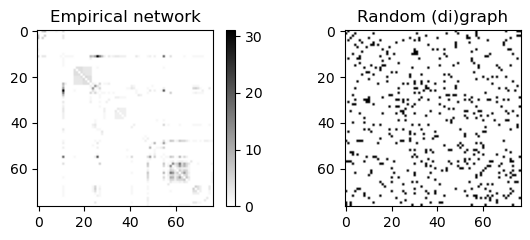

In [7]:
## GENERATE A RANDOM BINARY GRAPH, FROM AN EMPIRICAL NETWORK

# 1) Load an empirical network (CHOOSE ONE realnet)
dataroot = "./Data/"
# realnet = np.loadtxt(dataroot + 'Cat53_cortex.txt', dtype='uint8')
# realnet = np.loadtxt(dataroot + 'Zachary.txt', dtype='uint8')
# realnet = galib.tools.LoadFromPajek(dataroot + 'Dolphins.net', getlabels=False)
realnet = galib.tools.LoadFromPajek(dataroot + 'LesMiserables.net', getlabels=False)

# 2) Generate an equivalent binary random graph (CHOOSE ONE)
# rnet = galib.models.ErdosRenyiGraph_Like(realnet)
rnet = galib.models.RandomGraph_Like(realnet)


#######################################################################################
## NO NEED TO EDIT FROM HERE ##########################################################

# 3) Compare their fundamental characteristics
dir_real = galib.is_directed(realnet)
dir_rand = galib.is_directed(rnet)
print( f'Is the network directed?  Empirical: {dir_real}  |  random: {dir_rand} ' )

Nreal = len(realnet); Nrand = len(rnet)
print( f'Number of nodes N ...\tEmpirical: {Nreal:d}  |  random: {Nrand:d} ' )

dens_real = galib.Density(realnet)
dens_rand = galib.Density(rnet)
print( f'Density of the net ...\tEmpirical: {dens_real:1.4f}  |  random: {dens_rand:1.4f} ' )

Lreal = realnet.astype(bool).sum()
Lrand = rnet.sum()
print( f'Number of links L ...\tEmpirical: {Lreal:d}  |  random: {Lrand:d} ' )

Lreal_diag = realnet.astype(bool).trace()
Lrand_diag = rnet.trace()
print( f'Number self-loops ...\tEmpirical: {Lreal_diag:d}  |  random: {Lrand_diag:d} ' )
print()


# 4) Plot the two adjacency matrices
plt.figure(figsize=(9,2.5))
plt.subplot(1,3,1)
plt.title( 'Empirical network' )
plt.imshow(realnet, cmap='gray_r')
plt.colorbar()

plt.subplot(1,3,2)
plt.title( 'Random (di)graph' )
plt.imshow(rnet, cmap='gray_r')

plt.tight_layout()


Now, we will do the same but **seeding random weights** to the resulting random graph.

Is the network directed?  Empirical: False  |  random: False 
Number of nodes N ...	Empirical: 34  |  random: 34 
Density of the net ...	Empirical: 0.1390  |  random: 0.1390 
Number of links L ...	Empirical: 156  |  random: 156 
Number self-loops ...	Empirical: 0  |  random: 0 



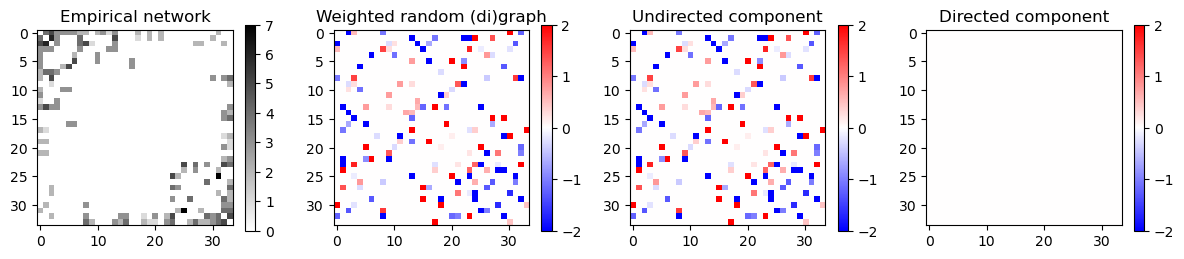

In [8]:
## GENERATE A RANDOM BINARY GRAPH FROM AN EMPIRICAL NETWORK, WITH RANDOM WEIGHTS
# This case is practically the same as the one before, only that here we
# pass a random number generator to the function via parameter `w_distr` 

# 1) Load an empirical network (CHOOSE ONE realnet)
dataroot = "./Data/"
# realnet = np.loadtxt(dataroot + 'Cat53_cortex.txt', dtype='uint8')
realnet = np.loadtxt(dataroot + 'Zachary.txt', dtype='uint8')
# realnet = galib.tools.LoadFromPajek(dataroot + 'Dolphins.net', getlabels=False)
# realnet = galib.tools.LoadFromPajek(dataroot + 'LesMiserables.net', getlabels=False)


# 2) Generate an equivalent random graph with random weights
# Edit the parameters for the random weight distribution
_sym_w = None      # None, True, False
_w_distr = numpy.random.normal    # or, numpy.random.uniform
# _kwargs = {'low':0, 'high':1}   # For numpy.random.uniform
_kwargs = {'loc':0, 'scale':2}   # For numpy.random.normal


# Generate the matrix
wrnet = galib.models.RandomGraph_Like(realnet, sym_w=_sym_w, w_distr=_w_distr, **_kwargs)


#######################################################################################
## NO NEED TO EDIT FROM HERE ##########################################################

# 3) Compare their main characteristics
dir_real = galib.is_directed(realnet)
dir_rand = galib.is_directed(wrnet)
print( f'Is the network directed?  Empirical: {dir_real}  |  random: {dir_rand} ' )

Nreal = len(realnet); Nrand = len(wrnet)
print( f'Number of nodes N ...\tEmpirical: {Nreal:d}  |  random: {Nrand:d} ' )

dens_real = galib.Density(realnet)
dens_rand = galib.Density(wrnet)
print( f'Density of the net ...\tEmpirical: {dens_real:1.4f}  |  random: {dens_rand:1.4f} ' )

Lreal = realnet.astype(bool).sum()
Lrand = wrnet.astype(bool).sum()
print( f'Number of links L ...\tEmpirical: {Lreal:d}  |  random: {Lrand:d} ' )

Lreal_diag = realnet.astype(bool).trace()
Lrand_diag = rnet.astype(bool).trace()
print( f'Number self-loops ...\tEmpirical: {Lreal_diag:d}  |  random: {Lrand_diag:d} ' )
print()


# 4) Plot the adjacency matrices
# Define the masks for the reciprocal and the directed components
mask = wrnet.astype(np.bool)
mask_und = mask * mask.T
mask_dir = mask ^ mask_und

wrnet_und = wrnet * mask_und
wrnet_dir = wrnet * mask_dir

# Plot the figure
plt.figure(figsize=(12,2.5))

plt.subplot(1,4,1)
plt.title( 'Empirical network' )
plt.imshow(realnet, cmap='gray_r')
plt.colorbar()

plt.subplot(1,4,2)
plt.title( 'Weighted random (di)graph' )
plt.imshow(wrnet, cmap='bwr')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,4,3)
plt.title( 'Undirected component' )
plt.imshow(wrnet_und, cmap='bwr')
plt.clim(-2,2)
plt.colorbar()

plt.subplot(1,4,4)
plt.title( 'Directed component' )
plt.imshow(wrnet_dir, cmap='bwr')
plt.clim(-2,2)
plt.colorbar()

plt.tight_layout()


> **Note that**, if `ErdosRenyi_Like()` and `RandomGraph_Like()` are called with `w_distr = False`, the return a binary (digraph) encoded as an matrix (ndarray) of `np.uint8` dtype. But if a random number generator function is passed to `w_distr`, the output will be an matrix of `np.float64` dtype.

### 3.2 - Randomising link weights only

When empirical network *A* is weighted, we may want to understand the influence of the weights alone on results (e.g., if we are running a dynamical process on *A*) without altering the underlying structure. And, we may not know with certainty the distribution of its link weights. In that case we can use the link weights of *A* to construct other weighted surrogates by randomly shuffling those weights among the links. We can do so with function `ShuffleWeights()`.  

The function has optional parameter `copy` to determine whether a new array is returned, or whether the weights of the input matrix are shuffled in-place, modifying *A*, as the following examples will show.

Binary structure conserved? True
Link weights conserved?     False



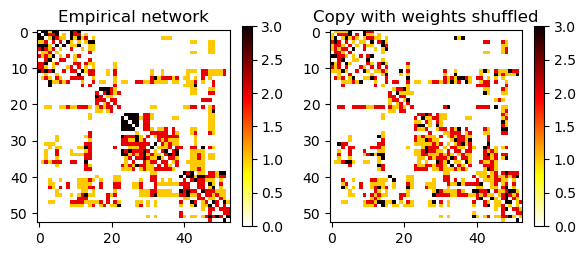

In [9]:
## LOAD AN EMPIRICAL WEIGHTED NETWORK AND CREATE A COPY WITH ITS WEIGHTS RANDOMLY SHUFFLED

# 1) Load an empirical network (CHOOSE ONE realnet)
dataroot = "./Data/"
realnet = np.loadtxt(dataroot + 'Cat53_cortex.txt', dtype='uint8')
# realnet = np.loadtxt(dataroot + 'Zachary.txt', dtype='uint8')
# realnet = galib.tools.LoadFromPajek(dataroot + 'LesMiserables.net', getlabels=False)


# 2) Make a copy with the weights shuffled
newnet = galib.models.ShuffleWeights(realnet, copy=True)


#######################################################################################
## NO NEED TO EDIT FROM HERE ##########################################################

# 3) Test the shuffling of weights is correctly done
same_struct = (realnet.astype(bool) == newnet.astype(bool)).all()
print( "Binary structure conserved?", same_struct )
same_weights = (realnet == newnet).all()
print( "Link weights conserved?    ", same_weights )
print()

# 4) Plot the adjacency matrices
plt.figure(figsize=(6,2.5))

plt.subplot(1,2,1)
plt.title( 'Empirical network' )
plt.imshow(realnet, cmap='hot_r')
plt.colorbar()

plt.subplot(1,2,2)
plt.title( 'Copy with weights shuffled' )
plt.imshow(newnet, cmap='hot_r')
plt.colorbar()

plt.tight_layout()


<br>

Now, we will do the same but shuffling the weights of `realnet` **in-place**, instead of creating a new matrix.
Notice that in this case we call the function without passing it to a variable:
```python
>>> # Make a new copy of `net`
>>> newnet = galib.models.ShuffleWeights(net, copy=True)
>>> # Randomise links of `net` in-place
>>> galib.models.ShuffleWeights(net, copy=False)
```


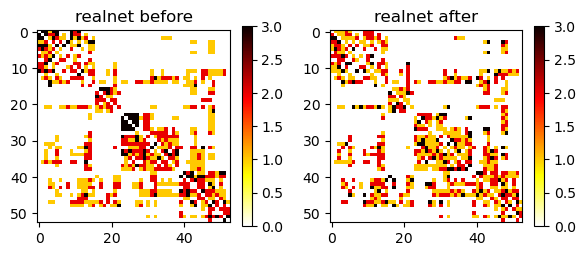

In [10]:
## LOAD AN EMPIRICAL WEIGHTED NETWORK AND RANDOMISE ITS WEIGHTS IN-PLACE

# 1) Load an empirical network (CHOOSE ONE realnet)
dataroot = "./Data/"
realnet = np.loadtxt(dataroot + 'Cat53_cortex.txt', dtype='uint8')
#realnet = np.loadtxt(dataroot + 'Zachary.txt', dtype='uint8')
#realnet = galib.tools.LoadFromPajek(dataroot + 'LesMiserables.net', getlabels=False)

# 2) Plot the the original `realnet` matrix
plt.figure(figsize=(6,2.5))

plt.subplot(1,2,1)
plt.title( 'realnet before' )
plt.imshow(realnet, cmap='hot_r')
plt.colorbar()


# 3) Shuffle the link weights of realnet, and replot
galib.models.ShuffleWeights(realnet, copy=False)

plt.subplot(1,2,2)
plt.title( 'realnet after' )
plt.imshow(realnet, cmap='hot_r')
plt.colorbar()

plt.tight_layout()


### 3.3. - Rewiring links and weights

A more general situation is when we want to randomise the structure of a network but conserve the degrees $k_i$ of all nodes $i = 1, 2, \ldots, N$. This can be achieved by link rewiring algorithms. Unfortunately, when the links are weighted, it is not possible to rewire a network and conserve both the degree and the strength (weighted degree, $s_i$) of the nodes. Except maybe in very particular cases.

When rewiring weighted networks we need to choose whether we will conserve the input sums or the output sums, and randomise the others. In *pyGAlib*, function `RewireNetwork()` does this job. It always returns the result in new matrix, instead of changing `adjmatrix` in-place, and for weighted networks it always conserves the input strengths. Until further updates, to conserve the output strengths the user can pass the transpose of the input matrix.

In the folowing examples we will:

1. load a weighted empirical network,
2. create a rewired binary version of the network, and
3. create a rewired weighted version of the network. 

And we will check the rewiring was correctly done.


Is the network directed?  Empirical: False  |  rewired: False 
Density of the networks	  Empirical: 0.0868  |  rewired: 0.0868 
Are degrees conserved?  Input: True  |  Output: True



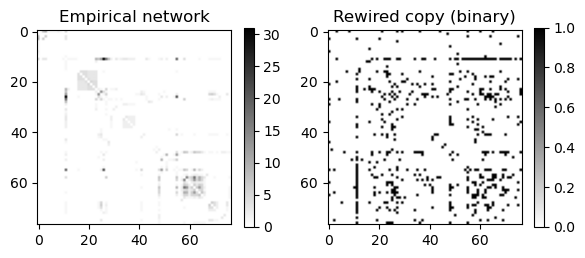

In [11]:
## LOAD AN EMPIRICAL WEIGHTED NETWORK AND RETURN A BINARY REWIRED VERSION
## THAT CONSERVES ITS (INPUT AND OUTPUT) DEGREES

# 1) Load an empirical network (CHOOSE ONE realnet)
dataroot = "./Data/"
#realnet = np.loadtxt(dataroot + 'Cat53_cortex.txt', dtype='uint8')
#realnet = np.loadtxt(dataroot + 'Zachary.txt', dtype='uint8')
realnet = galib.tools.LoadFromPajek(dataroot + 'LesMiserables.net', getlabels=False)


# 2) Make a copy with the weights shuffled
rewnet = galib.models.RewireNetwork(realnet, weighted=False)


#######################################################################################
## NO NEED TO EDIT FROM HERE ##########################################################

# 3) Test the rewiring was correctly done of weights is correctly done
dir_emp = galib.is_directed(realnet)
dir_rew = galib.is_directed(rewnet)
print( f'Is the network directed?  Empirical: {dir_emp}  |  rewired: {dir_rew} ' )

dens_emp = galib.Density(realnet)
dens_rew = galib.Density(rewnet)
print( f'Density of the networks\t  Empirical: {dens_emp:1.4f}  |  rewired: {dens_rew:1.4f} ' )

ink_emp, outk_emp = galib.Degree(realnet, directed=True)
ink_rew, outk_rew = galib.Degree(rewnet, directed=True)
print( f'Are degrees conserved?  Input: {(ink_emp ==ink_rew).all()}  |  Output: {(outk_emp ==outk_rew).all()}' )

print()


# 4) Plot the adjacency matrices
plt.figure(figsize=(6,2.5))

plt.subplot(1,2,1)
plt.title( 'Empirical network' )
plt.imshow(realnet, cmap='gray_r')
plt.colorbar()

plt.subplot(1,2,2)
plt.title( 'Rewired copy (binary)' )
plt.imshow(rewnet, cmap='gray_r')
plt.colorbar()

plt.tight_layout()


<br>
Now, let's repeat but including the weights in the rewiring.

Is the network directed?  Empirical: False  |  rewired: False 
Density of the networks	  Empirical: 0.0868  |  rewired: 0.0868 
Sum of weights ...	Empirical: 1640.0  |  rewired: 1640.0 
Are degrees conserved?  Input: True  |  Output: True
Are degrees conserved?  Input: True  |  Output: False



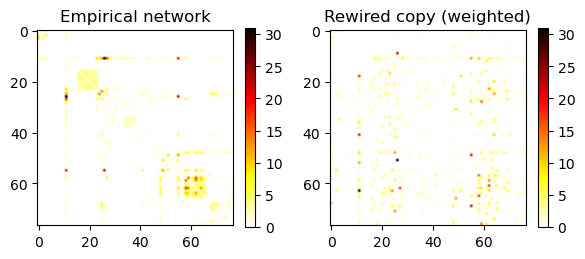

In [12]:
## LOAD AN EMPIRICAL WEIGHTED NETWORK AND RETURN A WEIGHTED REWIRED VERSION
## THAT CONSERVES ITS (INPUT AND OUTPUT) DEGREES AND STRENGTHS

# 1) Load an empirical network (CHOOSE ONE realnet)
dataroot = "./Data/"
#realnet = np.loadtxt(dataroot + 'Cat53_cortex.txt', dtype='uint8')
#realnet = np.loadtxt(dataroot + 'Zachary.txt', dtype='uint8')
realnet = galib.tools.LoadFromPajek(dataroot + 'LesMiserables.net', getlabels=False)


# 2) Make a copy with the weights shuffled
rewnet = galib.models.RewireNetwork(realnet, weighted=True)


#######################################################################################
## NO NEED TO EDIT FROM HERE ##########################################################

# 3) Test the rewiring was correctly done of weights is correctly done
dir_emp = galib.is_directed(realnet)
dir_rew = galib.is_directed(rewnet)
print( f'Is the network directed?  Empirical: {dir_emp}  |  rewired: {dir_rew} ' )

dens_emp = galib.Density(realnet)
dens_rew = galib.Density(rewnet)
print( f'Density of the networks\t  Empirical: {dens_emp:1.4f}  |  rewired: {dens_rew:1.4f} ' )

totalw_emp = realnet.sum()
totalw_rew = rewnet.sum()
print( f'Sum of weights ...\tEmpirical: {totalw_emp}  |  rewired: {totalw_rew} ' )

ink_emp, outk_emp = galib.Degree(realnet, directed=True)
ink_rew, outk_rew = galib.Degree(rewnet, directed=True)
print( f'Are degrees conserved?  Input: {(ink_emp ==ink_rew).all()}  |  Output: {(outk_emp ==outk_rew).all()}' )

ins_emp, outs_emp = galib.Intensity(realnet, directed=True)
ins_rew, outs_rew = galib.Intensity(rewnet, directed=True)
print( f'Are degrees conserved?  Input: {(ins_emp ==ins_rew).all()}  |  Output: {(outs_emp ==outs_rew).all()}' )

print()


# 4) Plot the adjacency matrices
plt.figure(figsize=(6,2.5))

plt.subplot(1,2,1)
plt.title( 'Empirical network' )
plt.imshow(realnet, cmap='hot_r')
plt.colorbar()

plt.subplot(1,2,2)
plt.title( 'Rewired copy (weighted)' )
plt.imshow(rewnet, cmap='hot_r')
plt.colorbar()

plt.tight_layout()
